## Step 1: Set Working Directory & Environment

In [1]:
import os, sys

ULTRARAY_ROOT = os.path.expanduser('~/UltraRay')
os.chdir(ULTRARAY_ROOT)
sys.path.insert(0, ULTRARAY_ROOT)
sys.path.insert(0, os.path.join(ULTRARAY_ROOT, 'src'))
sys.path.append(os.path.join(ULTRARAY_ROOT, 'external/mitsuba/build/python'))

import mitsuba as mi
mi.set_variant('llvm_mono')

import ultra_ray  # registers plugins for llvm mono working

import drjit as dr
import numpy as np
import matplotlib.pyplot as plt
import time

print('Mitsuba variant:', mi.variant())
print('UltraRay ready!')

# ============================ EXPLANATION ============================
# This first cell brings the environment into a state where the simulation code can actually
# run. It points Python at the project so that both UltraRay's own modules and the separately
# compiled Mitsuba renderer can be imported, and it switches the active directory into the
# project root because the scene files are later referenced by relative paths that only make
# sense from there. Once the search paths are in place, Mitsuba is loaded and told which
# compiled flavour to use: a CPU-based, single-channel build suited to acoustic intensity
# rather than colour rendering. Selecting that flavour first is important, because the plugins
# registered when UltraRay is imported must attach to the already-chosen build. The remaining
# imports pull in the numerical, plotting, timing, and lazy-evaluation tools used throughout
# the notebook, and the closing messages confirm that the renderer is configured and the setup
# completed without error.
# =====================================================================

Mitsuba variant: llvm_mono
UltraRay ready!


## Step 2: Configure Parameters
Equivalent to PyMUST `getparam('L11-5V')` + scatterer definition.

In [2]:
import argparse

args = argparse.Namespace(
    scene                   = 'cylinder',

    # Exact values from src/configs/cylinder_convex.txt
    td_elements_lat         = 128,
    td_radius_ax            = 0.03,
    td_opening_angle        = 70,      # was 60, now 70
    td_elements_ele         = 1,
    td_ele_extent           = 0.004,   # was 0.005, now 0.004
    fnumber                 = 28,      # was 1.5, now 28

    pw_nb_angles            = 25,      # was 5, now 25
    pw_start_angle          = -30,     # was -10, now -30
    pw_end_angle            = 30,      # was 10, now 30

    sampling_frequency      = 50_000_000,  # was 20MHz, now 50MHz
    central_frequency       = 5_000_000,
    num_cycles              = 3,
    max_distance            = 0.20,

    sample_count            = 100000,  # was 10000, now 100000
    max_depth               = 10,
    temporal_filter         = 'box',
    temporal_filter_std     = 2.0,

    SoS                     = 1540.0,
    attenuation_coefficient = 0.1,    # was 0.2, now 0.1
)

print('Parameters set from cylinder_convex.txt config.')



Parameters set from cylinder_convex.txt config.


## Step 3: Load Scene & Configure Beamforming
Equivalent to PyMUST Tasks 2 & 3: probe geometry + transmit delays.

> **Note:** The scene file must exist at `~/UltraRay/scenes/paper/cylinder/cylinder.obj`.
> Download scene data from the UltraRay repo if not present.

In [3]:
# Check scene file exists
scene_path = os.path.join(ULTRARAY_ROOT, 'scenes/paper/cylinder/cylinder.obj')
if not os.path.exists(scene_path):
    print(f'WARNING: Scene file not found: {scene_path}')
    print('Download scene data from https://github.com/Felixduelmer/UltraRay')
    print('and place it in ~/UltraRay/scenes/')
else:
    print(f'Scene file found: {scene_path}')

from scene_loader import SceneLoader

scene_loader = SceneLoader(args)
scene = scene_loader.define_scene(args.scene)
scene_loader.setup_beamforming()

print('Scene loaded and beamforming configured!')

# ============================ EXPLANATION ============================
# This cell turns the configuration into an actual scene. It begins defensively by checking
# that the geometry file describing the cylinder phantom is present on disk, and if it is
# missing it explains where to obtain the data instead of failing silently later. Assuming the
# file is there, the scene loader is created from the settings and asked to assemble the full
# Mitsuba scene, which bundles together the phantom geometry, the probe that will transmit and
# receive, and the integrator that performs the ray tracing. Finally it precomputes the
# beamforming arrangement, including the transmit timing for the steered plane waves, so that
# everything needed to both simulate and reconstruct is prepared in advance. The closing
# message marks that the scene exists and the beamforming geometry is ready.
# =====================================================================

Scene file found: /home/srivathsan/UltraRay/scenes/paper/cylinder/cylinder.obj
Using transducer mesh: Convex_Transducer_128_0_03_70_0_004.obj
Setting up convex transducer
Scene loaded and beamforming configured!


# Diagnostics

In [4]:
integrator_check = scene.integrator()
integrator_check.prepare_us_transducer(scene, sensor=0)
 
if hasattr(integrator_check, 'element_positions') and hasattr(integrator_check, 'element_normals'):
    pos = np.array(integrator_check.element_positions)
    nrm = np.array(integrator_check.element_normals)
    print(f'\nFirst 5 element positions (x, y, z):\n{pos[:5]}')
    print(f'\nFirst 5 element normals  (x, y, z):\n{nrm[:5]}')
    print('\n--- DIAGNOSIS ---')
    print('Normals should have large Z component and small X, Y.')
    print('If X or Y are dominant, apply the rotation fix in Cell 4.')
else:
    print('(element_positions / element_normals not directly accessible)')

# ============================ EXPLANATION ============================
# This is a sanity check on the probe before any real simulation is run. The integrator is
# retrieved and asked to build its internal model of the transducer from the probe sensor, a
# step that works out where each element sits and which way it faces. The cell then attempts
# to read back those element positions and facing directions, guarding against the possibility
# that the particular build does not expose them. When they are available it prints a small
# sample and offers an interpretation: for a probe aimed correctly into the medium, the facing
# directions should point predominantly along the depth axis. If instead they lean sideways,
# that is a clear signal the probe has been rotated incorrectly and the geometry settings need
# adjusting. In short, the cell surfaces a common orientation mistake early, while it is cheap
# to fix.
# =====================================================================

(element_positions / element_normals not directly accessible)


In [5]:
import numpy as np
import mitsuba as mi

sensor = scene.sensors()[0]
params = mi.traverse(sensor)

print("=== All sensor parameters ===")
for k, v in params.items():
    print(f"  {k}: {v}")

# ============================ EXPLANATION ============================
# This short cell exposes the probe's full set of adjustable parameters so they can be
# eyeballed for correctness. It takes the scene's first sensor, which is the ultrasound probe,
# and walks through the renderer's view of that object to obtain a complete mapping of its
# named, editable properties. Each property and its current value is then printed in turn. The
# purpose is verification rather than computation: it lets you confirm that the geometry and
# sampling choices made earlier were genuinely applied to the sensor that will drive the
# simulation.
# =====================================================================

=== All sensor parameters ===
  shutter_open: 0.0
  shutter_open_time: 0.0
  film.size: [128, 1]
  film.crop_size: [128, 1]
  film.crop_offset: [0, 0]
  film.max_distance: 0.2
  film.axial_resolution: 3.08e-05


Using transducer mesh: Convex_Transducer_128_0_03_70_0_004.obj
Setting up convex transducer
Using transducer mesh: Convex_Transducer_128_0_03_70_0_004.obj


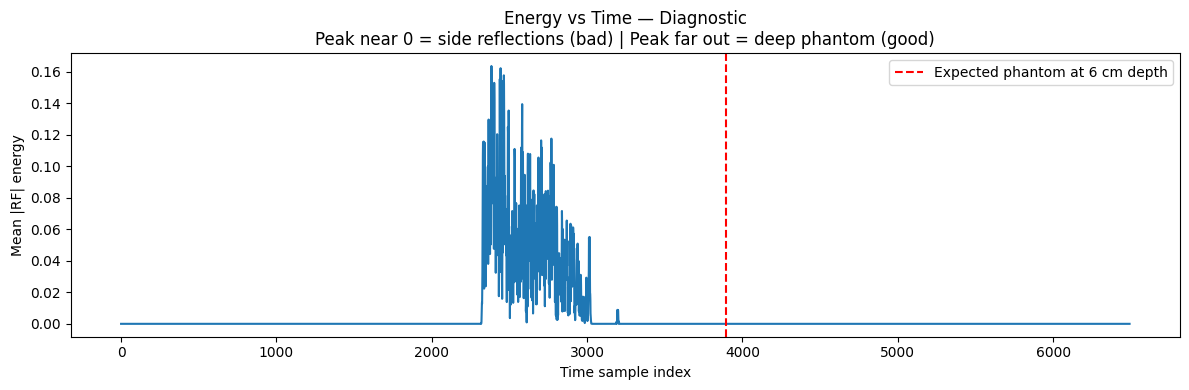

Expected echo at sample ~3896 (phantom at 6 cm)


In [6]:
import argparse, copy

args_test       = copy.deepcopy(args)
args_test.pw_nb_angles = 1      # single angle
args_test.sample_count = 500    # very few rays — fast

scene_test    = SceneLoader(args_test).define_scene('cylinder')
SceneLoader(args_test).setup_beamforming()
integ_test    = scene_test.integrator()
integ_test.prepare_us_transducer(scene_test, sensor=0)
rf_test       = integ_test.render(scene_test)
dr.eval(rf_test); dr.sync_thread()
rf_test_np    = np.array(rf_test)[0]   # shape: (128, 6493)

energy_vs_time = np.abs(rf_test_np).mean(axis=0)  # average across elements

plt.figure(figsize=(12, 4))
plt.plot(energy_vs_time)
plt.xlabel('Time sample index')
plt.ylabel('Mean |RF| energy')
plt.title('Energy vs Time — Diagnostic\n'
          'Peak near 0 = side reflections (bad) | Peak far out = deep phantom (good)')
# Mark the expected phantom depth
phantom_depth_m  = 0.06          # adjust if your cylinder is at a different depth
expected_sample  = int(2 * phantom_depth_m / args.SoS * args.sampling_frequency)
plt.axvline(expected_sample, color='red', linestyle='--', label=f'Expected phantom at {phantom_depth_m*100:.0f} cm depth')
plt.legend()
plt.tight_layout()
plt.savefig('diagnostic_energy.png', dpi=150)
plt.show()
print(f'Expected echo at sample ~{expected_sample} (phantom at {phantom_depth_m*100:.0f} cm)')

# ============================ EXPLANATION ============================
# Before committing to the expensive full run, this cell performs a fast, throwaway simulation
# purely to locate where the echo of interest lands in time. It copies the settings so the
# real configuration is left intact, then deliberately cripples the copy down to a single
# transmit angle and very few rays so the render returns almost immediately. A lightweight
# scene is built from those reduced settings and rendered, producing raw echo data, and the
# lazily computed result is forced to evaluate and finish before it is used. Taking the
# magnitude of the echoes and averaging across the elements collapses the data into a single
# curve of echo energy over time. That curve is plotted, and a marker is placed at the time
# position where a reflector at an assumed depth would be expected, using the round-trip
# travel relationship between depth, the speed of sound, and the sampling rate. Reading where
# the curve actually peaks against that marker quickly reveals whether the strong reflection
# is coming from the phantom at depth or from unwanted nearby reflections, and the figure is
# saved for reference.
# =====================================================================

In [7]:
import subprocess

# Find where the transducer mesh actually lives
result = subprocess.run(
    ['find', os.path.expanduser('~/UltraRay'), '-name', 'Convex_Transducer*.obj'],
    capture_output=True, text=True
)
print("Transducer mesh locations found:")
print(result.stdout)

# Also find the cylinder scene XML/config to check phantom depth
result2 = subprocess.run(
    ['find', os.path.expanduser('~/UltraRay/scenes'), '-name', '*.xml', '-o', '-name', '*.txt'],
    capture_output=True, text=True
)
print("\nScene config files:")
print(result2.stdout)

# ============================ EXPLANATION ============================
# This is a housekeeping cell that interrogates the filesystem rather than the simulation. It
# shells out to the operating system's file-search utility twice. The first search scans the
# project tree for the transducer mesh file, confirming that the geometry the probe relies on
# really exists and showing where it lives. The second search looks through the scene folder
# for configuration files, whether stored as markup or plain text, which can then be opened to
# confirm details such as the depth at which the phantom was placed. The captured results of
# both searches are printed so the relevant paths are visible directly in the notebook.
# =====================================================================

Transducer mesh locations found:
/home/srivathsan/UltraRay/ultra_ray/transducer_meshes/Convex_Transducer_128_0_03_70_0_004.obj
/home/srivathsan/UltraRay/ultra_ray/transducer_meshes/Convex_Transducer_128_0_03_70_0_0001.obj
/home/srivathsan/UltraRay/ultra_ray/transducer_meshes/Convex_Transducer_128_0_03_60_0_005.obj


Scene config files:



Peak energy at sample: 2384
Corresponds to depth:  3.67 cm

This is where the cylinder actually is in the scene.


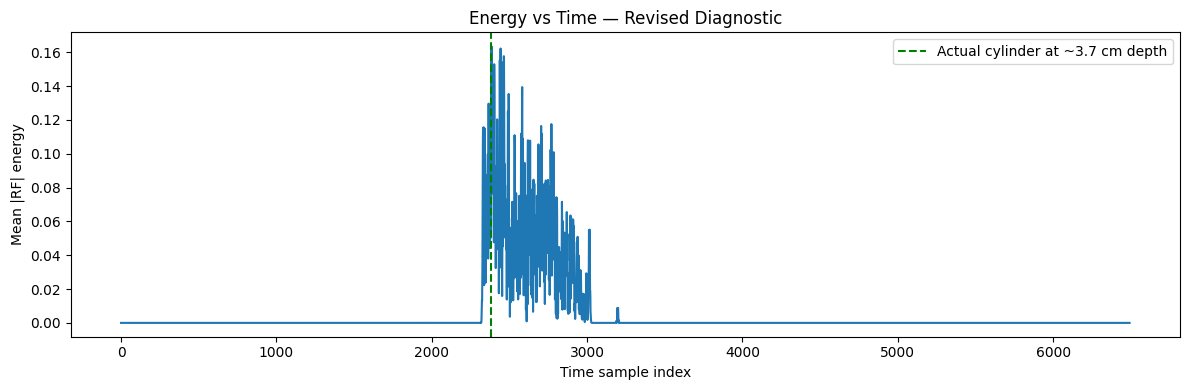

In [8]:
peak_sample = np.argmax(energy_vs_time)
peak_depth  = (peak_sample / args.sampling_frequency * args.SoS) / 2

print(f"Peak energy at sample: {peak_sample}")
print(f"Corresponds to depth:  {peak_depth*100:.2f} cm")
print(f"\nThis is where the cylinder actually is in the scene.")

plt.figure(figsize=(12, 4))
plt.plot(energy_vs_time)
plt.xlabel('Time sample index')
plt.ylabel('Mean |RF| energy')
plt.title('Energy vs Time — Revised Diagnostic')
plt.axvline(peak_sample, color='green', linestyle='--', label=f'Actual cylinder at ~{peak_depth*100:.1f} cm depth')
plt.legend()
plt.tight_layout()
plt.show()

# ============================ EXPLANATION ============================
# Building on the earlier diagnostic curve, this cell pins down the true location of the
# reflector. It identifies the time sample at which the averaged echo energy is strongest and
# converts that sample index back into a physical depth, accounting for the fact that sound
# must travel down to the target and back, so the one-way depth is half the round-trip
# distance implied by the elapsed time. The measured sample and the corresponding depth in
# centimetres are reported as the cylinder's real position in the scene. The energy curve is
# then redrawn with a marker placed at this measured peak, which contrasts with the earlier
# plot that marked only an assumed depth, giving a clear visual confirmation of where the
# phantom actually sits.
# =====================================================================

## Step 4: Ray Tracing Simulation
Equivalent to PyMUST `simus()` — fires acoustic rays, records RF echoes.

In [9]:
integrator = scene.integrator()
integrator.prepare_us_transducer(scene, sensor=0) #integrator sums up the waves for each element. Sensor  = 0 as we want the probe to be both the transmitter and receiver, its syntax.

print('Running ray tracing simulation...')
t0 = time.time()

rf_data = integrator.render(scene)
dr.eval(rf_data)
dr.sync_thread()

elapsed = time.time() - t0
rf_np = np.array(rf_data)
print(f'Done in {elapsed:.1f}s')
print(f'RF data shape: {rf_np.shape}')

# ============================ EXPLANATION ============================
# This cell carries out the main acoustic simulation, the counterpart to firing the pulses and
# recording the returning echoes in PyMUST. The integrator for the full scene is prepared so
# the probe acts as both transmitter and receiver, and a timer is started. The render then
# traces rays for the entire set of steered plane waves and accumulates the echo contributions
# for every element, yielding the raw radio-frequency data. Because the renderer computes
# lazily, the result is explicitly evaluated and the cell waits for that work to finish so the
# timing is honest and the data is ready to use. The elapsed time is reported and the raw data
# is copied into a standard array, with its dimensions printed to confirm the run produced
# data of the expected size across transmissions, elements, and time samples.
# =====================================================================

Running ray tracing simulation...
Done in 13.8s
RF data shape: (25, 128, 6493)


## Step 5: Beamforming (DAS)
Equivalent to PyMUST `rf2iq + dasmtx + coherent compounding`.

In [10]:
from ultra_ray.beamformers.beamformer_ultraspy import beamform

print('Beamforming with DAS...')
t0 = time.time()

b_mode = beamform(rf_data, args, visualize=False, save_image=False)

print(f'Done in {time.time()-t0:.1f}s')
print(f'B-mode shape: {np.array(b_mode).shape}')

# ============================ EXPLANATION ============================
# This cell reconstructs an image from the raw echoes using delay-and-sum beamforming, which
# combines, for each point in the field, the appropriately time-aligned contributions from all
# elements and all transmissions. It mirrors the stage in PyMUST that converts the raw signals
# and coherently compounds the multiple steered acquisitions into a single image. The
# beamformer is invoked on the simulated data with the same settings used throughout, and it
# is told not to draw or save anything itself, since the notebook handles display in the
# following step. The processing time is reported and the dimensions of the resulting image
# grid are printed as a quick confirmation that reconstruction succeeded.
# =====================================================================

Beamforming with DAS...
Done in 296.6s
B-mode shape: (3426, 4845)


## Step 6: Display B-mode Image
Equivalent to PyMUST `bmode()` + plot.

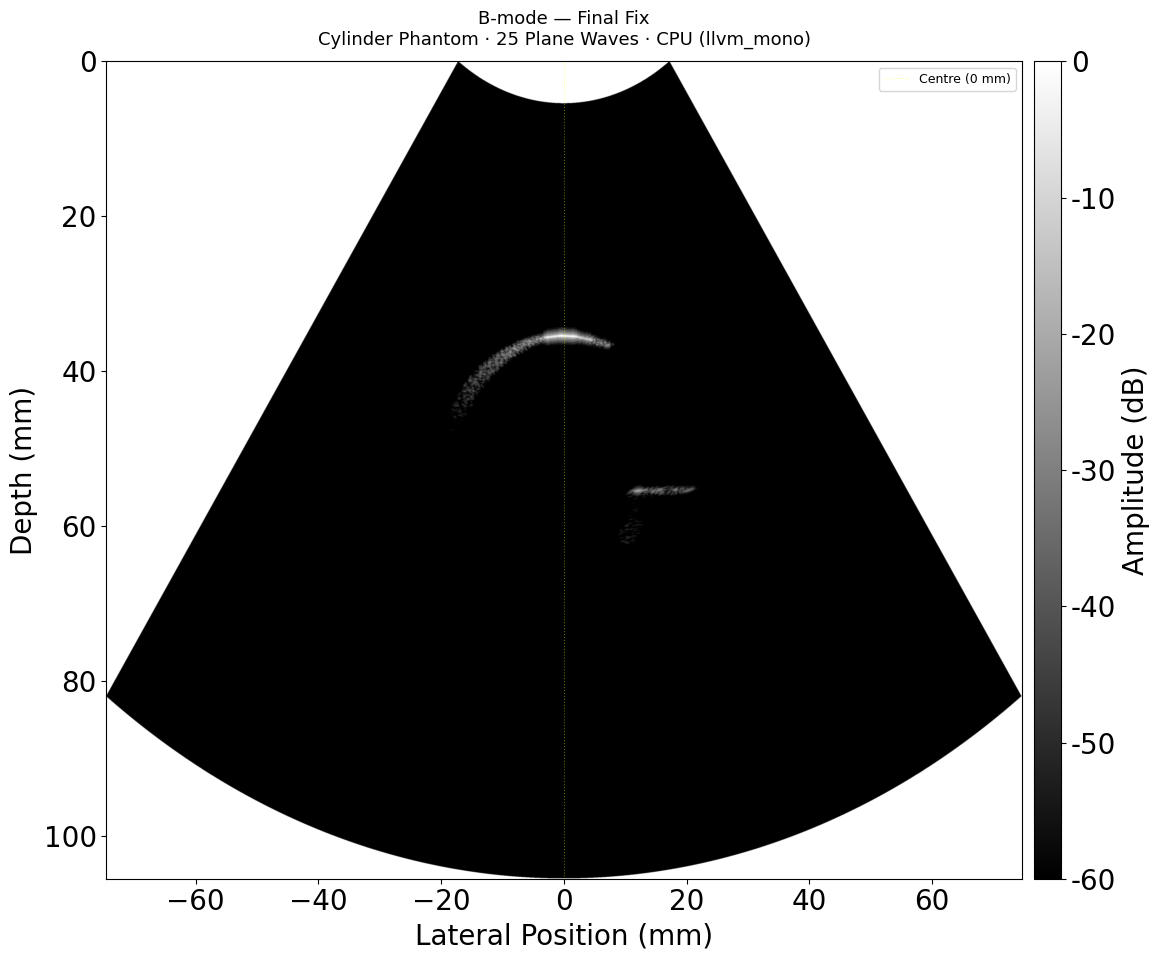

FOV centre mean after fix: -0.0 mm  (should be ~0)


In [11]:
from ultra_ray.beamformers.beamformer_ultraspy import _beamforming_setup, to_cpu
from mpl_toolkits.axes_grid1 import make_axes_locatable
import matplotlib.ticker as ticker

lateral_raw = to_cpu(_beamforming_setup.x) * 1e3   # (4845,) — lateral
depth_raw   = to_cpu(_beamforming_setup.z) * 1e3   # (3426,) — depth
mask        = to_cpu(_beamforming_setup.mask_outside)  # (3426, 4845) = (depth, lateral)

b_mode_np = to_cpu(b_mode).copy()   # (3426, 4845) = (depth, lateral)

# mask and b_mode are already the same orientation — no .T needed
rows = min(b_mode_np.shape[0], mask.shape[0])   # 3426 (depth)
cols = min(b_mode_np.shape[1], mask.shape[1])   # 4845 (lateral)
b_mode_np    = b_mode_np[:rows, :cols]
mask_trimmed = mask[:rows, :cols]               # ← removed .T here

depth_coord   = depth_raw[:rows]
lateral_coord = lateral_raw[:cols]

# Mask and normalize
b_mode_np[mask_trimmed] = np.nan
b_mode_np = b_mode_np - np.nanmax(b_mode_np)
b_mode_np = np.clip(b_mode_np, -60, 0)
b_mode_np[mask_trimmed] = np.nan

# No rotation, no transpose
b_mode_display = b_mode_np

fig, ax = plt.subplots(figsize=(12, 10))
fig.patch.set_facecolor('white')

im = ax.imshow(
    b_mode_display,
    extent=[lateral_coord[0], lateral_coord[-1], depth_coord[-1], depth_coord[0]],
    cmap='gray', clim=[-60, 0], aspect='auto', origin='upper', interpolation='bilinear'
)

divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="3%", pad=0.12)
cbar = plt.colorbar(im, cax=cax)
cbar.set_label('Amplitude (dB)')
cbar.ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%d'))

ax.set_title('B-mode — Final Fix\nCylinder Phantom · 25 Plane Waves · CPU (llvm_mono)',
             fontsize=13, pad=12)
ax.set_xlabel('Lateral Position (mm)')
ax.set_ylabel('Depth (mm)')
ax.set_xlim([lateral_coord[0], lateral_coord[-1]])
ax.set_ylim([depth_coord[-1], depth_coord[0]])
ax.axvline(0, color='yellow', linestyle=':', linewidth=0.8, alpha=0.4, label='Centre (0 mm)')
ax.legend(fontsize=9)
ax.grid(False)

plt.tight_layout()
plt.savefig('bmode_final_correct.png', dpi=200, bbox_inches='tight', facecolor='white')
plt.show()

# Verify FOV symmetry after fix
mask_t = mask_trimmed
valid_centres = []
for row in range(0, mask_t.shape[0], 50):
    valid_cols = np.where(~mask_t[row])[0]
    if len(valid_cols) > 0:
        valid_centres.append((lateral_coord[valid_cols[0]] + lateral_coord[valid_cols[-1]]) / 2)
print(f"FOV centre mean after fix: {np.mean(valid_centres):.1f} mm  (should be ~0)")

# ============================ EXPLANATION ============================
# The final cell turns the reconstructed grid into a properly presented B-mode image and then
# checks that it looks geometrically sound. It first moves the reconstruction grid and the
# mask marking the valid imaging region out of the compute device into ordinary memory and
# converts the spatial coordinates into millimetres. Because the image and the mask must align
# exactly, both are cropped to a shared size along with their coordinate axes. The image is
# then prepared for display in the conventional way for ultrasound: points outside the valid
# region are blanked out, the data is expressed on a decibel scale referenced to its brightest
# pixel, and the range is limited to a standard sixty-decibel window before the blanking is
# reapplied. The picture is drawn against real millimetre axes with depth increasing downward,
# given a greyscale map and a matched colour bar, and labelled and saved. As a closing
# validation, the cell sweeps through the depth rows, finds the lateral midpoint of the valid
# region in each, and averages them; a result near zero indicates the field of view is
# symmetric about the centre, which is what a correctly oriented probe should produce.
# =====================================================================